## Question 1

A blob is a region in an image that:
Has similar intensity or color,
    Differs significantly from the surrounding background,
    And usually represents a localized feature or object.

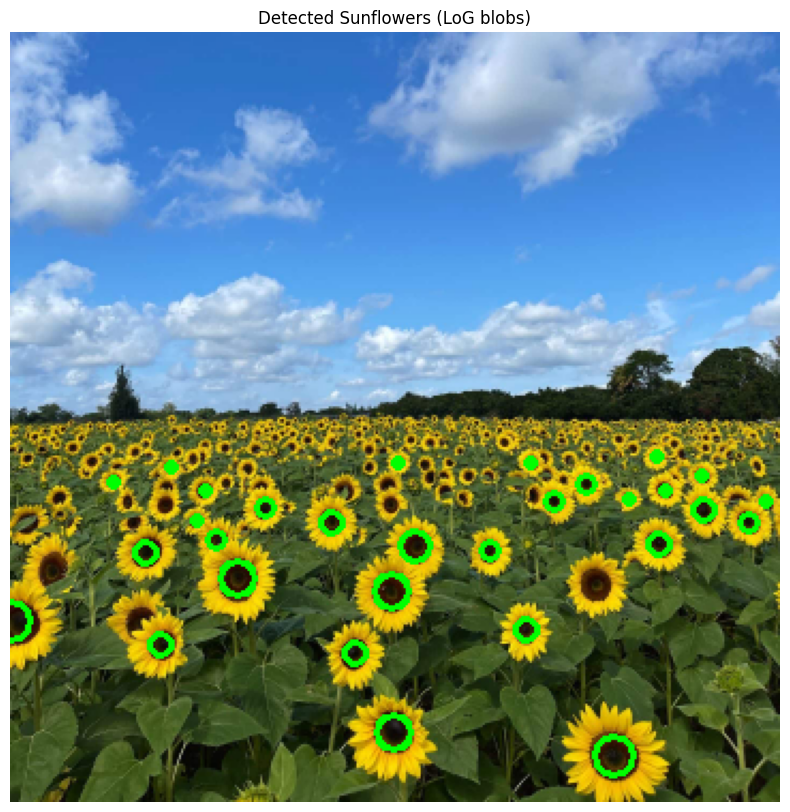

Output image saved as 'sunflower_blobs_detected.png'
Largest Circle Parameters:
 Center: (0, 275)
 Radius: 9.90 pixels
 Corresponding σ: 7.00
 σ range used: 1.00 – 10.00


In [29]:
import cv2 as cv
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt

im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
gray = gray / 255.0  # normalize to [0, 1]

#Scale-space parameters
sigma_values = np.linspace(1, 10, 10) 
h, w = gray.shape
response_stack = np.zeros((h, w, len(sigma_values)))
# Laplacian of Gaussian (LoG) response for each σ
for i, sigma in enumerate(sigma_values):
    blurred = cv.GaussianBlur(gray, (0, 0), sigma)
    log_resp = cv.Laplacian(blurred, cv.CV_64F)
    response_stack[:, :, i] = np.abs(log_resp) * (sigma ** 2)
# Local maxima across space and scale
maxima = (response_stack == ndi.maximum_filter(response_stack, size=(3, 3, 3)))

# Get coordinates of blob centers
y, x, s = np.where(maxima)
radii = np.sqrt(2) * sigma_values[s]

# Pick top N strongest blobs
strength = response_stack[y, x, s]
indices = np.argsort(strength)[-30:]  # top 30
y, x, s, radii = y[indices], x[indices], s[indices], radii[indices]

output = im.copy()
for (xi, yi, ri) in zip(x, y, radii):
    cv.circle(output, (int(xi), int(yi)), int(ri), (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title("Detected Sunflowers (LoG blobs)")
plt.axis("off")
plt.show()

cv.imwrite('sunflower_blobs_detected.png', output)
print("Output image saved as 'sunflower_blobs_detected.png'")

largest_idx = np.argmax(radii)
print("Largest Circle Parameters:")
print(f" Center: ({x[largest_idx]}, {y[largest_idx]})")
print(f" Radius: {radii[largest_idx]:.2f} pixels")
print(f" Corresponding σ: {sigma_values[s[largest_idx]]:.2f}")
print(f" σ range used: {sigma_values[0]:.2f} – {sigma_values[-1]:.2f}")


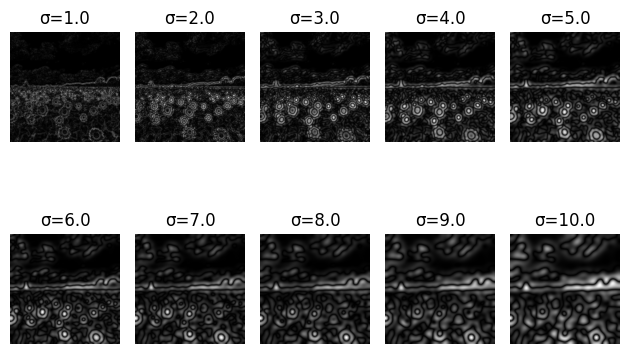

In [30]:
import matplotlib.pyplot as plt

for i, sigma in enumerate(sigma_values):
    plt.subplot(2, 5, i+1)
    plt.imshow(response_stack[:, :, i], cmap='gray')
    plt.title(f"σ={sigma:.1f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## Question 2

In [31]:
!pip install tikzplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


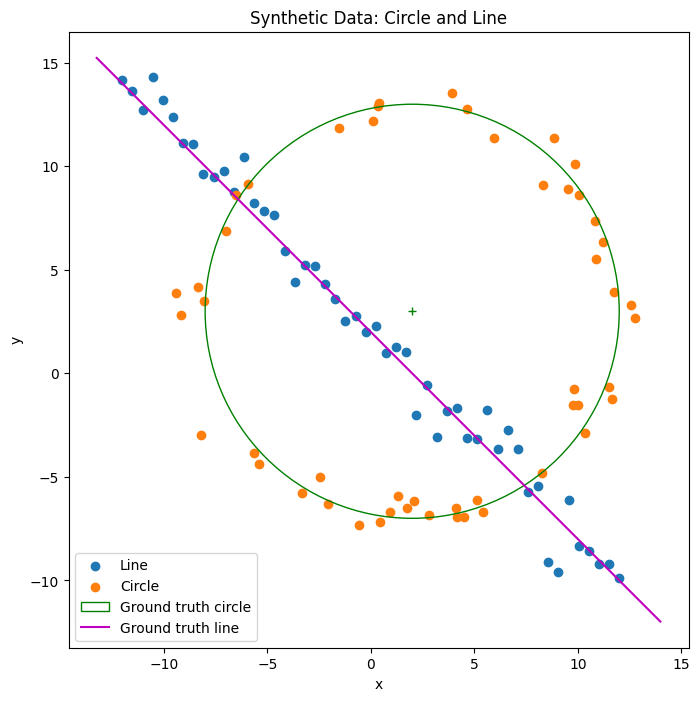

In [32]:
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
# import tikzplotlib

# np.random.seed(0)  # Uncomment for reproducibility

N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Circle center
s = r / 16

# ---- Circle points ----
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x = x0_gt + (r + n) * np.cos(t)
y = y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# ---- Line points ----
s = 1.0
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# ---- Combine all points ----
X = np.vstack((X_circ, X_line))

# ---- Plot ----
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')

# Ground truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), '+', color='g')

# Ground truth line
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Data: Circle and Line')
plt.axis('equal')
plt.show()


Estimated line parameters (a,b,d): (0.708, 0.707, -1.543)
Constraint ||[a,b]|| = 1.000
Number of inliers: 43 / 100


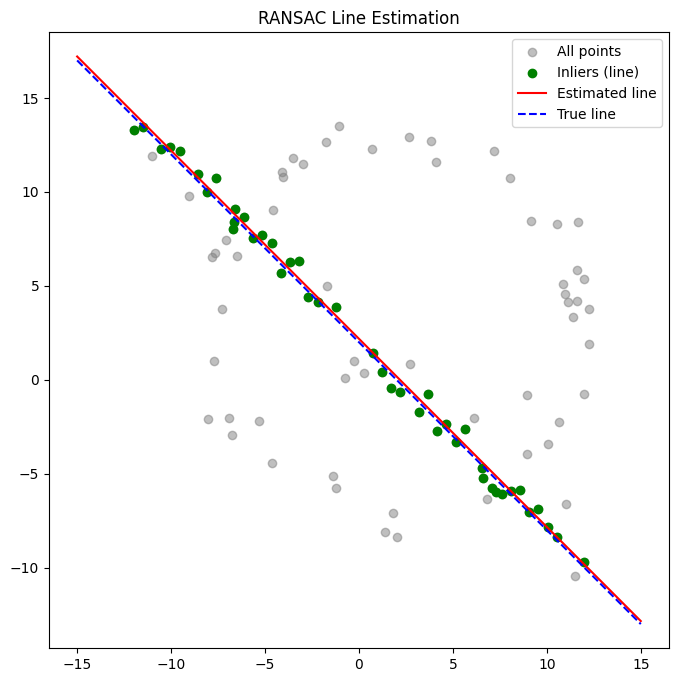

In [33]:
import numpy as np
import matplotlib.pyplot as plt


N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3
s = r / 16

t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x = x0_gt + (r + n) * np.cos(t)
y = y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

s = 1.0
m_true, b_true = -1, 2
x = np.linspace(-12, 12, half_n)
y = m_true * x + b_true + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

X = np.vstack((X_circ, X_line))

def fit_line_normal_form(p1, p2):
    """Fit line in normal form: ax + by + d = 0, with ||[a,b]||=1."""
    (x1, y1), (x2, y2) = p1, p2
    dx, dy = x2 - x1, y2 - y1
    a, b = dy, -dx # Normal vector (perpendicular to direction)
    norm = np.sqrt(a**2 + b**2)
    a, b = a / norm, b / norm
    d = -(a * x1 + b * y1)
    return a, b, d
def point_line_distance(X, a, b, d):
    """Compute perpendicular distance from points to line."""
    return np.abs(a * X[:, 0] + b * X[:, 1] + d)
# RANSAC Line Implementation
def ransac_line(X, n_iterations=1000, dist_threshold=0.7, min_inliers=30):
    best_inliers = []
    best_model = None
    for _ in range(n_iterations):
        # Randomly choose 2 distinct points
        sample_idx = np.random.choice(len(X), 2, replace=False)
        p1, p2 = X[sample_idx]
        # Fit line model
        a, b, d = fit_line_normal_form(p1, p2)
        # Compute distances to all points
        distances = point_line_distance(X, a, b, d)
        # Determine inliers
        inliers = np.where(distances < dist_threshold)[0]
        # Update best model
        if len(inliers) > len(best_inliers) and len(inliers) > min_inliers:
            best_inliers = inliers
            best_model = (a, b, d)
    return best_model, best_inliers

# -------------------------------
# Run RANSAC
# -------------------------------
best_model, best_inliers = ransac_line(X, n_iterations=1000, dist_threshold=0.7, min_inliers=30)
a, b, d = best_model

print(f"Estimated line parameters (a,b,d): ({a:.3f}, {b:.3f}, {d:.3f})")
print(f"Constraint ||[a,b]|| = {np.sqrt(a**2 + b**2):.3f}")
print(f"Number of inliers: {len(best_inliers)} / {len(X)}")

# -------------------------------
# Visualize results
# -------------------------------
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], color='gray', alpha=0.5, label='All points')
plt.scatter(X[best_inliers, 0], X[best_inliers, 1], color='green', label='Inliers (line)')

# Plot estimated line
x_vals = np.linspace(-15, 15, 100)
y_vals = (-a * x_vals - d) / b
plt.plot(x_vals, y_vals, 'r-', label='Estimated line')

# Ground truth line (for reference)
y_gt = m_true * x_vals + b_true
plt.plot(x_vals, y_gt, 'b--', label='True line')

plt.axis('equal')
plt.legend()
plt.title("RANSAC Line Estimation")
plt.show()


Estimated circle center: (1.761, 2.699), radius: 10.093
Number of inliers: 34 / 57


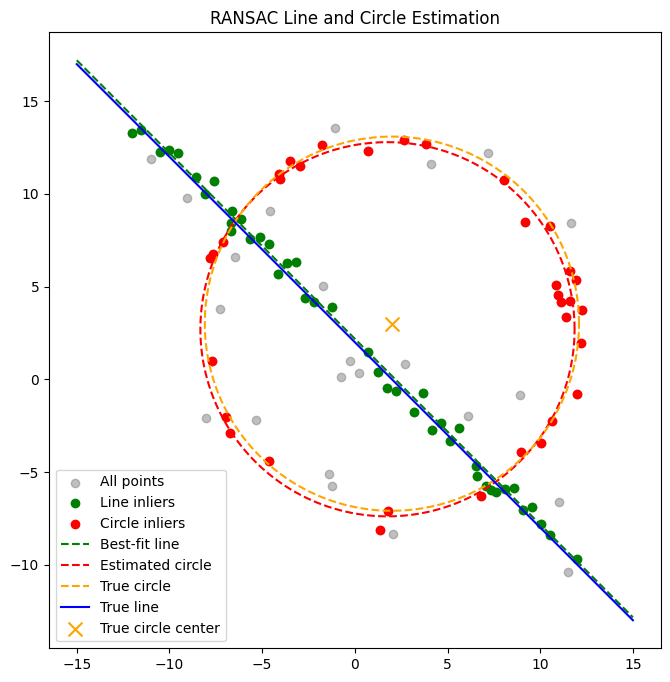

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -------------------------------
# Circle generation functions
# -------------------------------
def fit_circle_3pts(p1, p2, p3):
    """Fit circle through 3 points."""
    A = np.array([
        [2*(p2[0]-p1[0]), 2*(p2[1]-p1[1])],
        [2*(p3[0]-p1[0]), 2*(p3[1]-p1[1])]
    ])
    B = np.array([
        [p2[0]**2 + p2[1]**2 - p1[0]**2 - p1[1]**2],
        [p3[0]**2 + p3[1]**2 - p1[0]**2 - p1[1]**2]
    ])
    try:
        center = np.linalg.solve(A, B).flatten()
        r = np.linalg.norm(center - p1)
        return center[0], center[1], r
    except np.linalg.LinAlgError:
        return None
def circle_radial_error(X, cx, cy, r):
    """Compute radial error for all points."""
    return np.abs(np.sqrt((X[:,0]-cx)**2 + (X[:,1]-cy)**2) - r)
# RANSAC for circle
def ransac_circle(X, n_iterations=1000, dist_threshold=0.7, min_inliers=25):
    best_inliers = []
    best_model = None
    N = len(X)
    for _ in range(n_iterations):
        sample_idx = np.random.choice(N, 3, replace=False)
        p1, p2, p3 = X[sample_idx]
        res = fit_circle_3pts(p1, p2, p3)
        if res is None:
            continue
        cx, cy, r = res
        errors = circle_radial_error(X, cx, cy, r)
        inliers = np.where(errors < dist_threshold)[0]
        if len(inliers) > len(best_inliers) and len(inliers) >= min_inliers:
            best_inliers = inliers
            best_model = (cx, cy, r)
    # refine using all inliers
    if best_model is not None and len(best_inliers) >= 3:
        def circle_error(params):
            cx, cy, r = params
            return np.sum((np.sqrt((X[best_inliers,0]-cx)**2 + (X[best_inliers,1]-cy)**2) - r)**2)
        res = minimize(circle_error, best_model)
        best_model = res.x

    return best_model, best_inliers

# -------------------------------
# Remove line inliers from X
# -------------------------------
mask = np.ones(len(X), dtype=bool)
for idx in best_inliers:
    mask[idx] = False
X_rem = X[mask]

# -------------------------------
# Run RANSAC circle
# -------------------------------
circle_model, circle_inliers = ransac_circle(X_rem, n_iterations=1000, dist_threshold=0.7, min_inliers=30)
cx, cy, r = circle_model

print(f"Estimated circle center: ({cx:.3f}, {cy:.3f}), radius: {r:.3f}")
print(f"Number of inliers: {len(circle_inliers)} / {len(X_rem)}")

# -------------------------------
# Plot all results
# -------------------------------
plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], color='gray', alpha=0.5, label='All points')
plt.scatter(X[best_inliers,0], X[best_inliers,1], color='green', label='Line inliers')
plt.scatter(X_rem[circle_inliers,0], X_rem[circle_inliers,1], color='red', label='Circle inliers')

# Plot estimated line
x_vals = np.linspace(-15, 15, 100)
y_vals = (-a*x_vals - d)/b
plt.plot(x_vals, y_vals, 'g--', label='Best-fit line')

# Plot estimated circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), 'r--', label='Estimated circle')

# Plot true circle
plt.plot(x0_gt + r*np.cos(theta), y0_gt + r*np.sin(theta), 'orange', linestyle='--', label='True circle')
#plt.scatter(x0_gt, y0_gt, color='orange', marker='x', s=100, label='True circle center')

# Ground truth line and circle
y_gt = m_true * x_vals + b_true
plt.plot(x_vals, y_gt, 'b-', label='True line')

plt.scatter(x0_gt, y0_gt, color='orange', marker='x', s=100, label='True circle center')
plt.gca().set_aspect('equal')
plt.legend()
plt.title("RANSAC Line and Circle Estimation")

plt.savefig("ransac_line_circle.png", dpi=300)  # PNG format, high resolution

plt.show()


In [35]:
# -------------------------------
# Circle first
# -------------------------------
circle_model_first, circle_inliers_first = ransac_circle(X, n_iterations=1000, dist_threshold=0.7, min_inliers=25)
cx_first, cy_first, r_first = circle_model_first

print(f"Circle-first estimate: center=({cx_first:.3f},{cy_first:.3f}), radius={r_first:.3f}")
print(f"Circle inliers: {len(circle_inliers_first)} / {len(X)}")

# Remove circle inliers to fit line (optional)
mask = np.ones(len(X), dtype=bool)
mask[circle_inliers_first] = False
X_rem_line = X[mask]

# Fit line on remaining points (optional)
best_model_line_after, line_inliers_after = ransac_line(X_rem_line, n_iterations=1000, dist_threshold=0.7, min_inliers=30)
a_after, b_after, d_after = best_model_line_after
print(f"Line-after-circle: a={a_after:.3f}, b={b_after:.3f}, d={d_after:.3f}, inliers={len(line_inliers_after)}")

# -------------------------------
# Plot results
# -------------------------------
plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], color='gray', alpha=0.5, label='All points')

# Circle-first inliers
plt.scatter(X[circle_inliers_first,0], X[circle_inliers_first,1], color='red', label='Circle inliers (circle first)')

# Plot estimated circle
theta = np.linspace(0,2*np.pi,200)
plt.plot(cx_first + r_first*np.cos(theta), cy_first + r_first*np.sin(theta), 'r--', label='Estimated circle (circle first)')

# Optional: plot line after circle
x_vals = np.linspace(-15,15,100)
y_vals = (-a_after*x_vals - d_after)/b_after
plt.plot(x_vals, y_vals, 'g--', label='Line after circle')

# Ground truth
plt.plot(x_vals, m_true*x_vals+b_true, 'b-', label='True line')
plt.plot(x0_gt + r*np.cos(theta), y0_gt + r*np.sin(theta), 'orange', linestyle='--', label='True circle')
plt.scatter(x0_gt, y0_gt, color='orange', marker='x', s=100, label='True circle center')

plt.gca().set_aspect('equal')
plt.legend()
plt.title("RANSAC: Circle First Demonstration")
plt.show()


Circle-first estimate: center=(-908.192,-916.119), radius=1291.422
Circle inliers: 42 / 100


TypeError: cannot unpack non-iterable NoneType object

## Question 3

In [ ]:
import cv2
import numpy as np

points = []

def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        cv2.circle(param, (x, y), 5, (0, 0, 255), -1)
        cv2.imshow("Architectural Image", param)

arch_img = cv2.imread("stadium.jpg")
flag_img = cv2.imread("sanga.jpg")

clone = arch_img.copy()

cv2.imshow("Architectural Image", clone)
cv2.setMouseCallback("Architectural Image", click_event, clone)

print("Click exactly 4 points and then press any key.")
cv2.waitKey(0)
cv2.destroyAllWindows()

if len(points) != 4:
    raise ValueError("You must click exactly 4 points.")

pts_arch = np.array(points, dtype=np.float32)

h_flag, w_flag = flag_img.shape[:2]
pts_flag = np.array([[0, 0], [w_flag, 0], [w_flag, h_flag], [0, h_flag]], dtype=np.float32)

H, _ = cv2.findHomography(pts_flag, pts_arch)
warped_flag = cv2.warpPerspective(flag_img, H, (arch_img.shape[1], arch_img.shape[0]))
# Blend
flag_gray = cv2.cvtColor(warped_flag, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(flag_gray, 1, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)
arch_bg = cv2.bitwise_and(arch_img, arch_img, mask=mask_inv)
flag_fg = cv2.bitwise_and(warped_flag, warped_flag, mask=mask)
result = cv2.add(arch_bg, flag_fg)

cv2.imshow("Warped Flag Overlay", result)
cv2.imwrite("overlay_result_2.jpg", result)
cv2.waitKey(0)
cv2.destroyAllWindows()


Click exactly 4 points and then press any key.


## Question 4

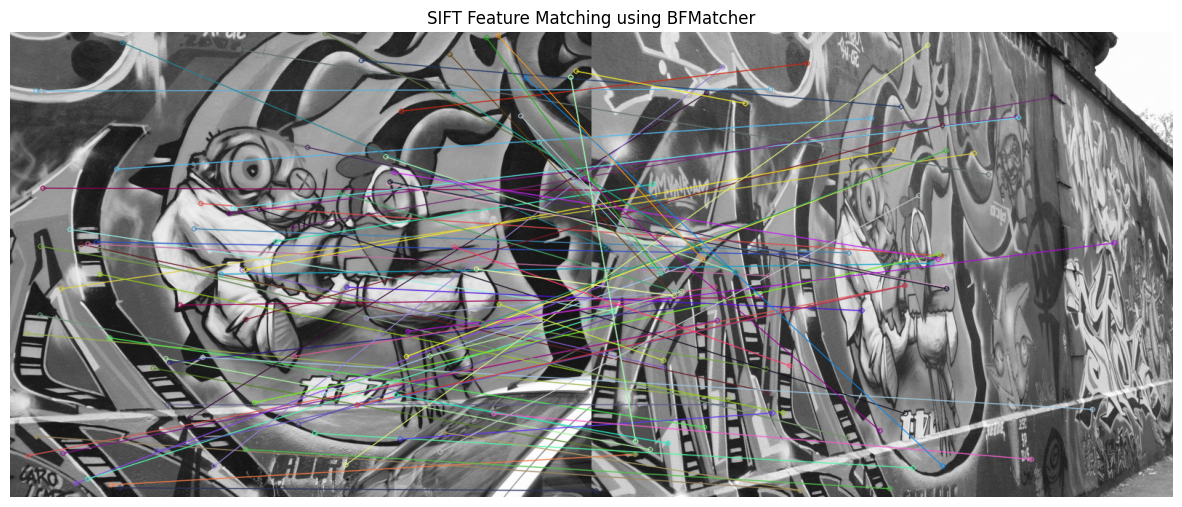

Number of keypoints in Image 1: 2674
Number of keypoints in Image 2: 3923
Number of good matches: 87


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('graf/img1.ppm')  # Portable Pixmap format
img2 = cv2.imread('graf/img5.ppm')

# Convert to grayscale (SIFT works only on intensity)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Use Brute-Force Matcher
# For SIFT, use L2-norm (Euclidean distance)
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# Match descriptors using KNN (k = 2)
matches = bf.knnMatch(des1, des2, k=2)

# Apply Lowe’s ratio test to keep only good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Draw matches
matched_img = cv2.drawMatches(gray1, kp1, gray2, kp2, good_matches, None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display result
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
cv2.imwrite('matched_image_bf.png', matched_img)
plt.title("SIFT Feature Matching using BFMatcher")
plt.axis('off')
plt.show()

# Print keypoint and match information
print(f"Number of keypoints in Image 1: {len(kp1)}")
print(f"Number of keypoints in Image 2: {len(kp2)}")
print(f"Number of good matches: {len(good_matches)}")


**BF Matcher**
The **Brute-Force Matcher (BFMatcher)** is the simplest and most direct method for feature matching. It works by comparing every descriptor from one image with every descriptor from the other image to find the best match based on distance (usually Euclidean distance for SIFT). Essentially, it checks all possible pairs and selects the one with the smallest distance as the best match. Since this exhaustive search compares each feature with all others, it guarantees accurate matches but can be slower for large descriptor sets. To improve reliability, techniques like **k-nearest neighbors (KNN)** and **Lowe’s ratio test** are often applied on top of BFMatcher to filter out ambiguous or incorrect matches.

The Euclidean distance between two descriptors quantifies how close their patterns are in this high-dimensional space.

Small distance → descriptors are very similar → likely the same physical point in the scene.

Large distance → descriptors are different → likely not a match.

**FLANN** stands for Fast Library for Approximate Nearest Neighbors.

When you extract SIFT descriptors, each keypoint is represented as a 128-dimensional vector.
To find matches between two images, you must find for each descriptor in img1 the most similar descriptor in img2.
This is basically a nearest neighbor search in high-dimensional space.

FLANN stands for Fast Library for Approximate Nearest Neighbors.

When you extract SIFT descriptors, each keypoint is represented as a 128-dimensional vector.
To find matches between two images, you must find for each descriptor in img1 the most similar descriptor in img2.
This is basically a nearest neighbor search in high-dimensional space.

algorithm=FLANN_INDEX_KDTREE → suitable for SIFT/SURF descriptors (floating-point data).

trees=5 → number of trees in the KD-Tree index (more trees → better accuracy, slower).

checks=50 → number of search iterations (higher = more accurate but slower).

KNN (k-Nearest Neighbors) Matching

When we call:
matches = flann.knnMatch(des1, des2, k=2)
We ask FLANN to find, for each descriptor in image 1, its k = 2 nearest matches in image 2.

For each pair (m, n) (best and 2nd-best matches):

Compute their descriptor distances:
m.distance (best), n.distance (second-best)

Accept m only if:

𝑚
.
𝑑
𝑖
𝑠
𝑡
𝑎
𝑛
𝑐
𝑒
<
ratio ×
𝑛
.
𝑑
𝑖
𝑠
𝑡
𝑎
𝑛
𝑐
𝑒

If the best match is much better than the second, the feature is unique → good.

If both are similar, the match is ambiguous → discard it.

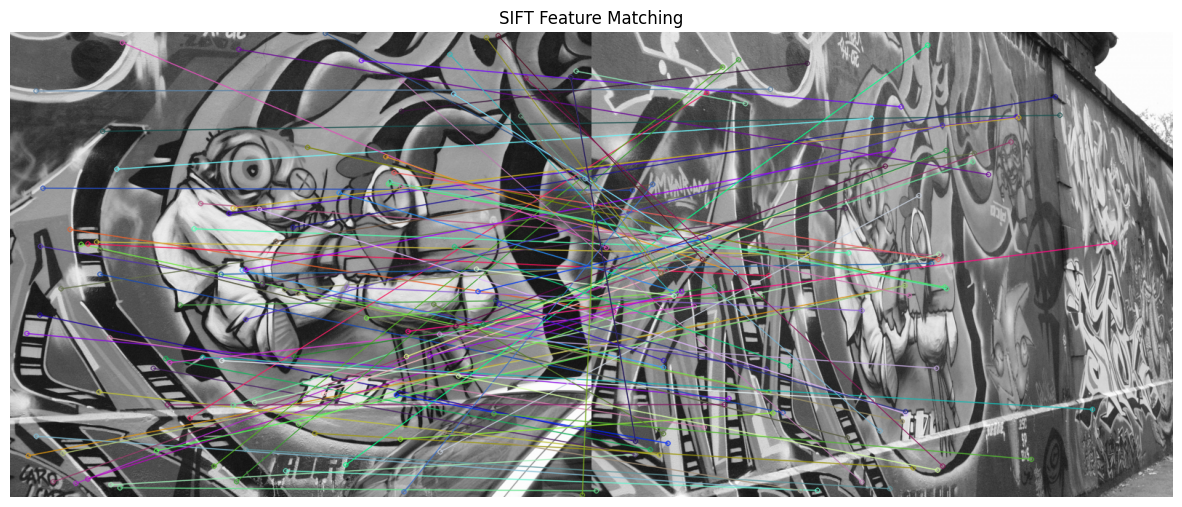

Number of keypoints in Image 1: 2674
Number of keypoints in Image 2: 3923
Number of good matches: 107


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('graf/img1.ppm') #Portable Pixmap
img2 = cv2.imread('graf/img5.ppm')

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) #SIFT works only on intensity information, not color.
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY) #This step reduces computation and focuses on texture and gradients

# Initialize SIFT detector
sift = cv2.SIFT_create() #SIFT detects keypoints (interesting points) and computes descriptors (vectors describing the local patch).

# Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Use FLANN-based matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Match descriptors using KNN
matches = flann.knnMatch(des1, des2, k=2)

# Apply Lowe’s ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Draw matches
matched_img = cv2.drawMatches(gray1, kp1, gray2, kp2, good_matches, None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display result
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
cv2.imwrite('matched_image_flann.png', matched_img)
plt.title("SIFT Feature Matching")
plt.axis('off')
plt.show()

print(f"Number of keypoints in Image 1: {len(kp1)}")
print(f"Number of keypoints in Image 2: {len(kp2)}")
print(f"Number of good matches: {len(good_matches)}")


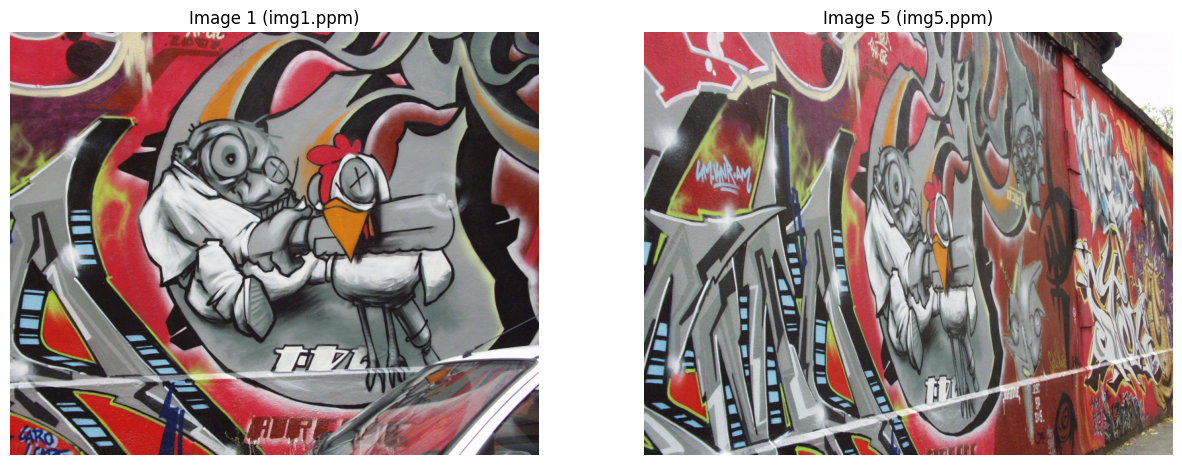

In [28]:
import cv2
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('graf/img1.ppm')
img2 = cv2.imread('graf/img5.ppm')

# Convert BGR → RGB for correct colors in matplotlib
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Display images side by side
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title("Image 1 (img1.ppm)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title("Image 5 (img5.ppm)")
plt.axis('off')

plt.show()


Good matches: 87
RANSAC inliers: 8/87
Estimated Homography:
 [[ 2.53131067e+00  1.98419636e+00  2.95221514e+00]
 [ 1.95794065e+00 -9.21507597e-01  1.47976557e+03]
 [ 5.81660451e-03  2.90822460e-03  1.00000000e+00]]


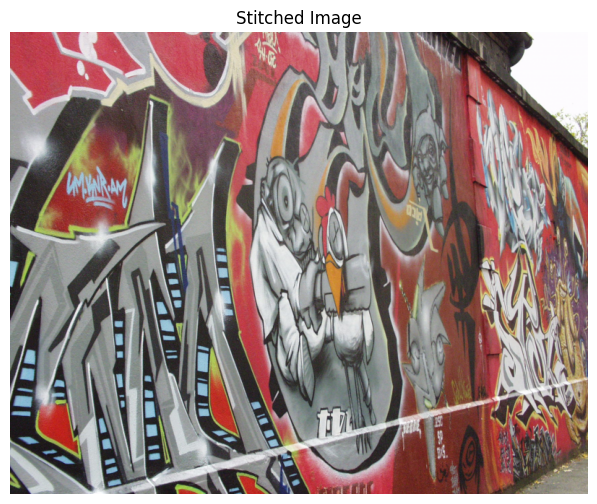

In [ ]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Read images
# -----------------------------
img1 = cv2.imread('graf/img1.ppm')  # Image to be stitched
img5 = cv2.imread('graf/img5.ppm')  # Base image

# -----------------------------
# Step 2: SIFT features
# -----------------------------
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp5, des5 = sift.detectAndCompute(img5, None)

# -----------------------------
# Step 3: Match descriptors with Lowe's ratio test
# -----------------------------
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des5, k=2)
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
print(f"Good matches: {len(good_matches)}")

# -----------------------------
# Step 4: RANSAC helper functions
# -----------------------------
def compute_homography(src_pts, dst_pts):
    """Compute homography from 4 points using DLT"""
    A = []
    for i in range(4):
        x, y = src_pts[i][0], src_pts[i][1]
        u, v = dst_pts[i][0], dst_pts[i][1]
        A.append([-x, -y, -1, 0, 0, 0, u*x, u*y, u])
        A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    return H / H[2, 2]
def get_inliers(H, src_pts, dst_pts, threshold=3.0):
    """Compute inliers for homography"""
    pts = np.hstack([src_pts, np.ones((len(src_pts),1))])
    projected = (H @ pts.T).T
    projected /= projected[:,2][:, np.newaxis]
    dists = np.linalg.norm(projected[:, :2] - dst_pts, axis=1)
    inliers = np.where(dists < threshold)[0]
    return inliers
def ransac_homography(src_pts, dst_pts, iterations=2000, threshold=5.0):
    best_H = None
    best_inliers = []
    n_points = 4
    for i in range(iterations):
        idx = np.random.choice(len(src_pts), n_points, replace=False)
        H = compute_homography(src_pts[idx], dst_pts[idx])
        inliers = get_inliers(H, src_pts, dst_pts, threshold)
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_H = H
    print(f"RANSAC inliers: {len(best_inliers)}/{len(src_pts)}")
    # Recompute H with all inliers
    if best_H is not None and len(best_inliers) > 4:
        best_H = compute_homography(src_pts[best_inliers[:4]], dst_pts[best_inliers[:4]])
    return best_H

# -----------------------------
# Step 5: Extract matched points
# -----------------------------
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([kp5[m.trainIdx].pt for m in good_matches])

# -----------------------------
# Step 6: Compute homography with RANSAC
# -----------------------------
H = ransac_homography(src_pts, dst_pts)
print("Estimated Homography:\n", H)

# -----------------------------
# Step 7: Warp img1 onto img5
# -----------------------------
h5, w5 = img5.shape[:2]
h1, w1 = img1.shape[:2]

# Warp img1 using the homography
warped_img1 = cv2.warpPerspective(img1, H, (w5, h5))

# Simple blending using mask
mask = (warped_img1 > 0).astype(np.uint8)
stitched = img5.copy()
stitched[mask[:,:,0]==1] = warped_img1[mask[:,:,0]==1]

# -----------------------------
# Step 8: Display results
# -----------------------------
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
cv2.imwrite('stitched_image.png', stitched)
plt.title("Stitched Image")
plt.axis('off')
plt.show()
